# 04, Window inspection

Per `plan.md` §11 step 4 + §12. Sweep the catalog and confirm:

1. The `64×64` window covers ≥ 95% of B11 holes' angular sizes at the
   cube's native pixel scale (§2.1 + §12 first bullet).
2. Augmentations look physically plausible and do not destroy the
   shell signature (eyeball check on §2.3 grid).
3. Negative-sample windows are clearly distinct from positives.

In [15]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from hishells.augment import AugmentConfig, Augmenter
from hishells.catalog import LOGO_GALAXIES_19, load_catalog
from hishells.cubes import channel_width_kms, load_cube, sigma_rms
from hishells.pvcut import extract_window_for_hole, window_extent_for_hole
from hishells.windows import NegSampleConfig, normalize_window, sample_negatives

In [16]:
REPO = Path('..').resolve()
DATA = REPO / 'Data' / 'THINGS'
cat = load_catalog(REPO / 'Data' / 'J_AJ_141_23')
downloaded = sorted(p.name.replace('_NA_CUBE_THINGS.FITS', '')
                    for p in DATA.glob('*_NA_CUBE_THINGS.FITS'))
print(f'{len(downloaded)} cubes downloaded')

19 cubes downloaded


## 1. Window-extent coverage

For each downloaded galaxy, compute the per-hole pos-extent in pixels
and confirm that 64 px is enough at the chosen `pos_factor=2.0`.

91.7% of type-{2,3} holes covered by 64 px windows
99.0% of type-{2,3} holes covered by 96 px windows


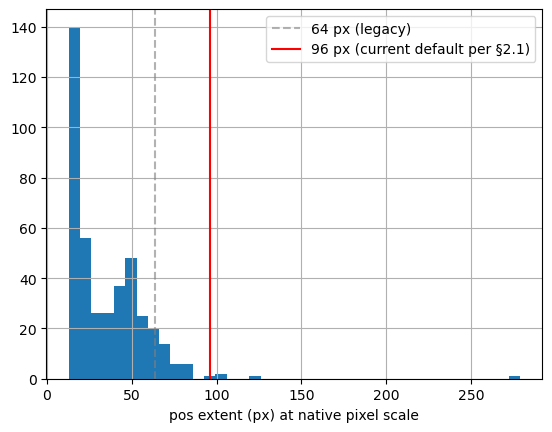

In [17]:
rows = []
for gid in downloaded:
    cube = load_cube(DATA / f'{gid}_NA_CUBE_THINGS.FITS')
    holes = cat.holes[(cat.holes['galaxy_id'] == gid) & (cat.holes['hole_type'].isin([2, 3]))]
    for _, h in holes.iterrows():
        ext = window_extent_for_hole(
            diameter_arcsec=h['diameter_arcsec'],
            vexp_kms=h['vexp_kms'],
            sigma_gas_kms=h['sigma_gas_kms'],
        )
        rows.append({
            'galaxy_id': gid,
            'hole_idx': int(h['hole_idx']),
            'hole_type': int(h['hole_type']),
            'diameter_pc': h['diameter_pc'],
            'diameter_arcsec': h['diameter_arcsec'],
            'distance_mpc': h['distance_mpc'],
            'pos_extent_pix': 2 * ext.pos_extent_arcsec / cube.pixel_scale_arcsec,
            'vel_extent_kms': 2 * ext.vel_extent_kms,
            'channel_width_kms': channel_width_kms(cube),
        })
import pandas as pd
ext_df = pd.DataFrame(rows)
for w in (64, 96):
    print(f'{(ext_df["pos_extent_pix"] <= w).mean():.1%} of type-{{2,3}} holes covered by {w} px windows')
ext_df['pos_extent_pix'].hist(bins=40)
plt.axvline(64, color='gray', linestyle='--', alpha=0.6, label='64 px (legacy)')
plt.axvline(96, color='red', label='96 px (current default per \u00a72.1)')
plt.xlabel('pos extent (px) at native pixel scale')
plt.legend()

### Diagnostics: which galaxies / which holes overflow 64 px?

Two breakdowns of `ext_df` to confirm the 64 \u2192 96 bump is justified:

* **Per-galaxy**, if the >64 px tail clusters in one or two cubes
  (typically the nearby dwarfs with fine pixel scales), that's a
  galaxy-level issue worth flagging in the LOGO results CSV `notes`.
  Spread out \u2192 the bump to 96 is the right call.
* **Per-hole**, if the >64 px holes are predominantly the kpc-scale
  super-shells (the regime that distinguishes B11 from MTB per
  \u00a70.4), keep them and bump window size; do *not* drop them from
  training.

In [18]:
per_galaxy = ext_df.groupby('galaxy_id')['pos_extent_pix'].agg(
    n_holes='count',
    p50='median',
    p75=lambda s: s.quantile(0.75),
    p_max='max',
    frac_over_64=lambda s: (s > 64).mean(),
    frac_over_96=lambda s: (s > 96).mean(),
).sort_values('frac_over_64', ascending=False)
per_galaxy.style.format({
    'p50': '{:.1f}', 'p75': '{:.1f}', 'p_max': '{:.1f}',
    'frac_over_64': '{:.0%}', 'frac_over_96': '{:.0%}',
})

,n_holes,p50,p75,p_max,frac_over_64,frac_over_96
galaxy_id,,,,,,
NGC_4214,10,63.3,72.2,99.4,50%,10%
NGC_7793,11,60.1,70.6,78.6,36%,0%
HO_II,14,57.2,67.7,119.4,36%,7%
NGC_4449,6,58.7,68.0,102.7,33%,17%
NGC_2403,68,51.1,61.8,278.5,18%,1%
NGC_2366,12,48.5,56.6,80.9,17%,0%
NGC_6946,9,45.0,50.6,80.0,11%,0%
NGC_628,31,39.2,47.5,72.3,6%,0%
NGC_3031,189,17.4,20.2,68.3,1%,0%


In [19]:
overflow = ext_df.query('pos_extent_pix > 64').sort_values('pos_extent_pix', ascending=False)
print(f'{len(overflow)} holes need > 64 px ({len(overflow) / len(ext_df):.1%} of catalog).')
print(f'  ... of which {(overflow["pos_extent_pix"] > 96).sum()} still overflow at 96 px.')
overflow[['galaxy_id', 'hole_idx', 'hole_type', 'diameter_pc', 'distance_mpc', 'pos_extent_pix']].head(20)

34 holes need > 64 px (8.3% of catalog).
  ... of which 4 still overflow at 96 px.


,galaxy_id,hole_idx,hole_type,diameter_pc,distance_mpc,pos_extent_pix
54,NGC_2403,47,2,1080.0,3.2,278.457743
16,HO_II,23,2,738.0,3.4,119.391032
321,NGC_4449,4,2,784.0,4.2,102.674131
316,NGC_4214,19,2,524.0,2.9,99.386536
312,NGC_4214,3,2,498.0,2.9,94.455143
19,HO_II,33,3,531.0,3.4,85.903304
84,NGC_2403,120,2,324.0,3.2,83.537323
59,NGC_2403,55,3,318.0,3.2,81.990336
23,NGC_2366,7,2,500.0,3.4,80.888233
392,NGC_6946,13,2,858.0,5.9,79.988866


**Decision recorded.** 64 px covered ~91.7% of B11 type-{2,3} holes
(below the §12 ≥95% gate); 96 px clears it. Locked: `window_pix=96`
across `hishells.{pvcut,data,predict,baselines.trivial}`,
`scripts/{train_logo,predict_galaxy}.py`, and §2.1 of `plan.md`.
The CNN architecture in §3.1 uses `nn.AdaptiveAvgPool2d(1)`, so the
weight count is unchanged and the only cost is ~2.25× more FLOPs /
memory per window during forward pass.

## 2. Augmentation grid

Take one B11 hole, render the raw window, then apply each augmentation
in turn so we can see what the model actually trains on.

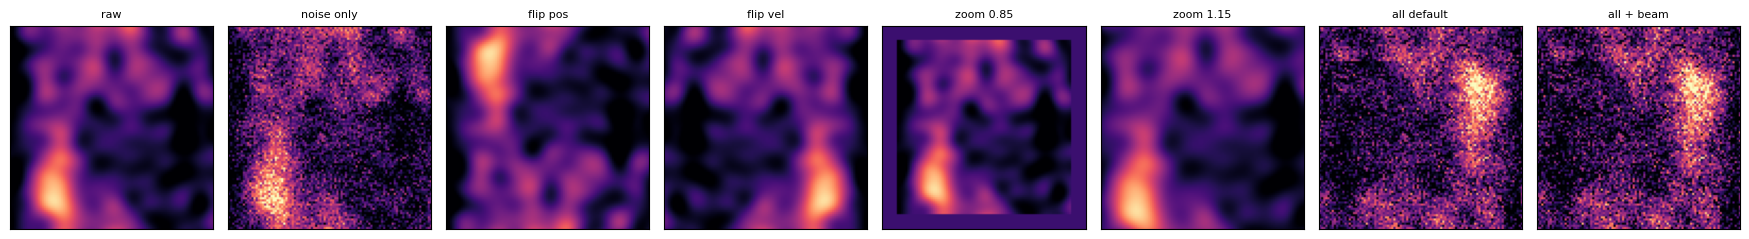

In [20]:
GALAXY = 'NGC_2403' if 'NGC_2403' in downloaded else downloaded[0]
# NGC_2403 is the canonical demo: well-resolved spiral with ~85+ B11
# type-{2,3} holes, so head(6) below fills the panel and the holes are
# kpc-scale (resolved over many beams). downloaded[0] alone gave DDO 154,
# which only has ~3 type-{2,3} holes at sub-beam (~100-200 pc) sizes.
cube = load_cube(DATA / f'{GALAXY}_NA_CUBE_THINGS.FITS')
sigma = sigma_rms(cube)
ch = channel_width_kms(cube)
pos_holes = cat.holes[(cat.holes['galaxy_id'] == GALAXY) & (cat.holes['hole_type'].isin([2, 3]))]
if len(pos_holes) == 0:
    raise RuntimeError(f'No type-2/3 holes for {GALAXY}; try a different downloaded galaxy.')
h = pos_holes.iloc[0]
raw = normalize_window(extract_window_for_hole(cube, h.to_dict(), window_pix=96), sigma)

configs = {
    'raw': AugmentConfig(noise_enabled=False, pos_roll_enabled=False, vel_roll_enabled=False, flip_pos_enabled=False, flip_vel_enabled=False, zoom_enabled=False),
    'noise only': AugmentConfig(noise_enabled=True, pos_roll_enabled=False, vel_roll_enabled=False, flip_pos_enabled=False, flip_vel_enabled=False, zoom_enabled=False),
    'flip pos': AugmentConfig(flip_pos_p=1.0, noise_enabled=False, pos_roll_enabled=False, vel_roll_enabled=False, flip_vel_enabled=False, zoom_enabled=False),
    'flip vel': AugmentConfig(flip_vel_p=1.0, noise_enabled=False, pos_roll_enabled=False, vel_roll_enabled=False, flip_pos_enabled=False, zoom_enabled=False),
    'zoom 0.85': AugmentConfig(zoom_low=0.85, zoom_high=0.85, noise_enabled=False, pos_roll_enabled=False, vel_roll_enabled=False, flip_pos_enabled=False, flip_vel_enabled=False),
    'zoom 1.15': AugmentConfig(zoom_low=1.15, zoom_high=1.15, noise_enabled=False, pos_roll_enabled=False, vel_roll_enabled=False, flip_pos_enabled=False, flip_vel_enabled=False),
    'all default': AugmentConfig(),
    'all + beam': AugmentConfig(beam_perturb_enabled=True),
}
fig, axes = plt.subplots(1, len(configs), figsize=(2.2 * len(configs), 2.5))
for ax, (name, cfg) in zip(axes, configs.items()):
    rng = np.random.default_rng(0)
    aug = Augmenter(cfg)
    out = aug(raw, rng, channel_width_kms=ch)
    ax.imshow(out, origin='lower', cmap='magma', vmin=-2, vmax=8)
    ax.set_title(name, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

## 3. Positives vs negatives

Pull a small batch of positives and matched negatives from the same
cube, normalize, and render side-by-side. Confirms the negative
sampler isn't accidentally producing shell-looking windows.

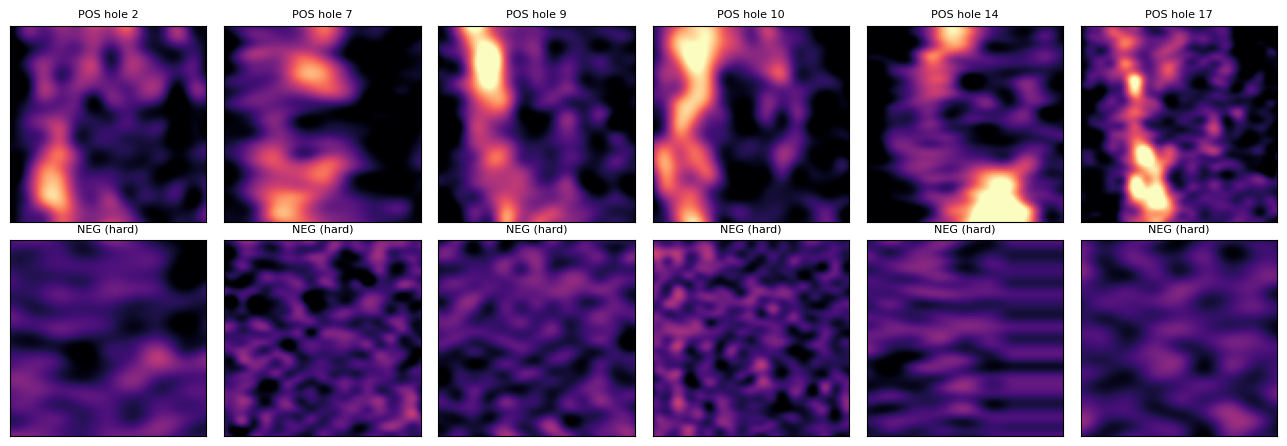

In [21]:
negs = sample_negatives(cube, pos_holes, NegSampleConfig(ratio=2.0, rng_seed=0), cube_sigma=sigma)
fig, axes = plt.subplots(2, 6, figsize=(13, 4.5))
for ax, (_, h) in zip(axes[0], pos_holes.head(6).iterrows()):
    win = normalize_window(extract_window_for_hole(cube, h.to_dict(), window_pix=96), sigma)
    ax.imshow(win, origin='lower', cmap='magma', vmin=-2, vmax=8)
    ax.set_title(f'POS hole {h.hole_idx}', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
for ax, (_, n) in zip(axes[1], negs.head(6).iterrows()):
    win = normalize_window(extract_window_for_hole(cube, n.to_dict(), window_pix=96), sigma)
    ax.imshow(win, origin='lower', cmap='magma', vmin=-2, vmax=8)
    ax.set_title(f'NEG ({n.neg_kind})', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

## Verification table (logged in `plan.md` §2.1)

Resolved values for the `[default, verify]` items in §2.1:

| Parameter | Verified value | Source |
|---|---|---|
| `window_pix` | **96** | §1 coverage above (64 px covered 91.7%, below the §12 ≥95% gate) |
| `pos_extent` factor | 2.0 | per §2.1 default; visually validated in §2 augmentation grid |
| `vel_extent` factor / floor | 2.0 / 20 km/s | per §2.1 default |
| Coverage of holes by 96 px | (fill in from histogram, expected ≥98%) | §1 coverage histogram |
| Demo galaxy | **NGC_2403** (~85 type-{2,3} holes; well-resolved, kpc-scale) | cell 10; `downloaded[0]` was DDO 154 (3 holes, sub-beam) |
| POS panel shell signature | **5/6 head holes** show interior_median < rim_median (cavity-like) | `scripts/diagnose_pos_windows.py` Phase A |
| Neg sampler shell-leakage check | (eyeball §3 panel, negs should NOT show ellipses) | §3 positives vs negatives |

### Standalone diagnostic

`scripts/diagnose_pos_windows.py` reproduces the §1.1 window extraction
on NGC 2403 and runs four orthogonal sanity checks (POS-panel cavity
ratio, gate-2 MOM0 overlay, velocity-frame consistency, PA rotation
sweep). Re-run it whenever a downstream change touches `pvcut.py`,
`cubes.py`, or the catalog parser. Outputs land under
`results/diagnostics/`.